In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df['target'].value_counts())

Shape: (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values: 0

Target distribution:
target
1    526
0    499
Name: count, dtype: int64


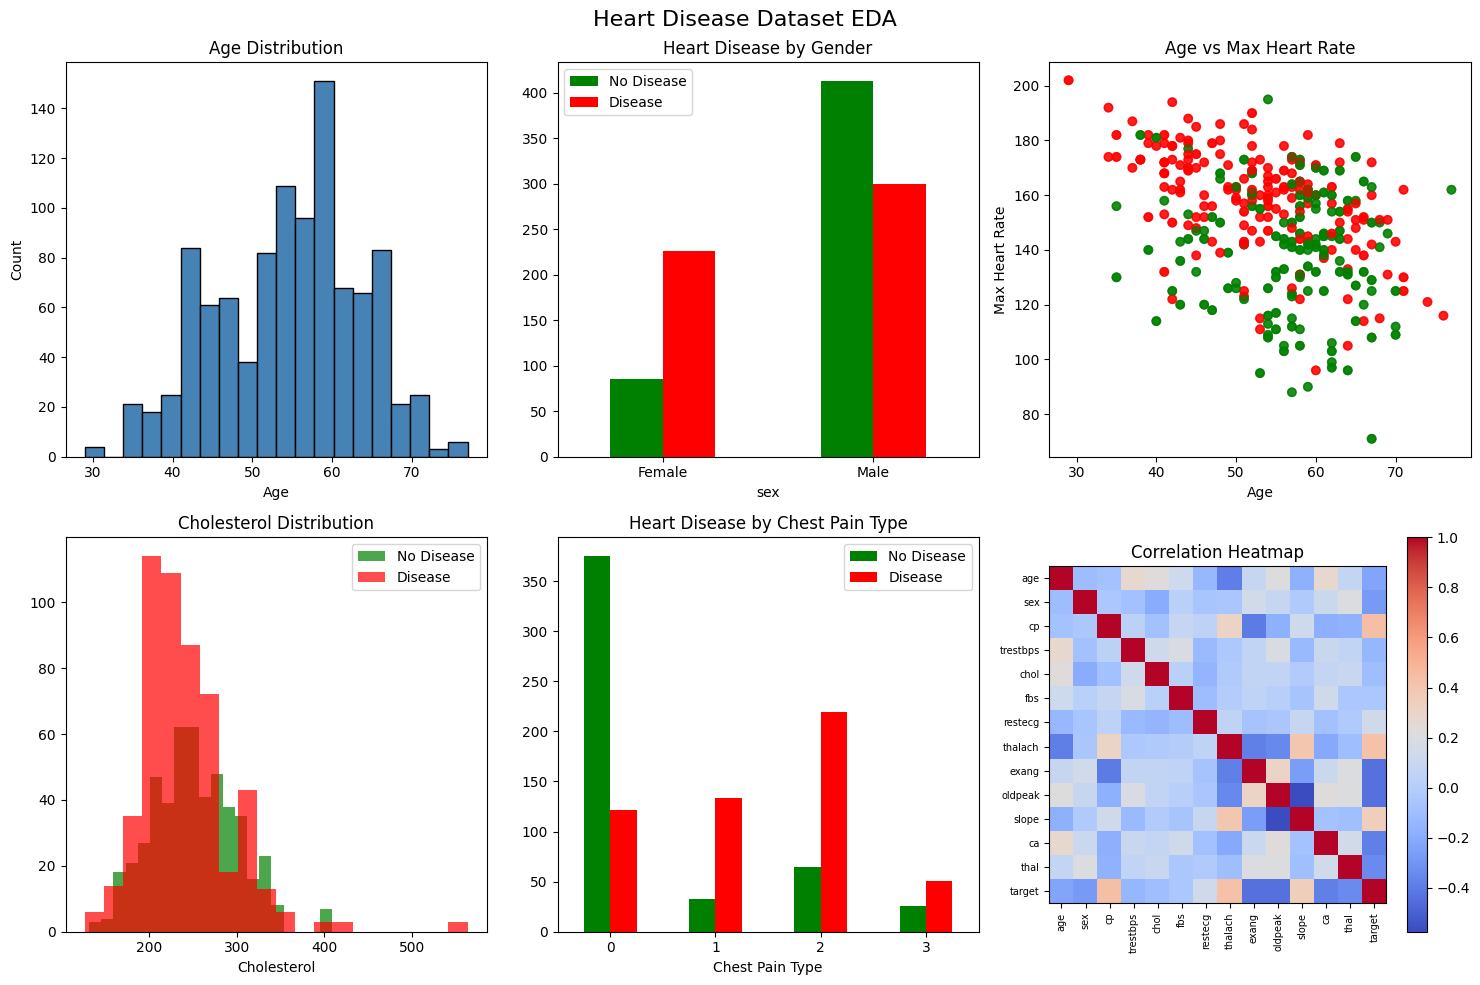

In [5]:
# Exploratory Data Analysis (EDA)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Heart Disease Dataset EDA', fontsize=16)

# Age distribution
axes[0, 0].hist(df['age'], bins=20, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# Heart disease by gender
sex_counts = df.groupby(['sex', 'target']).size().unstack()
sex_counts.plot(kind='bar', ax=axes[0, 1], color=['green', 'red'])
axes[0, 1].set_title('Heart Disease by Gender')
axes[0, 1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0, 1].legend(['No Disease', 'Disease'])

# Max heart rate vs age
colors = ['red' if t == 1 else 'green' for t in df['target']]
axes[0, 2].scatter(df['age'], df['thalach'], c=colors, alpha=0.5)
axes[0, 2].set_title('Age vs Max Heart Rate')
axes[0, 2].set_xlabel('Age')
axes[0, 2].set_ylabel('Max Heart Rate')

# Cholesterol distribution
axes[1, 0].hist(df[df['target']==0]['chol'], bins=20, alpha=0.7, color='green', label='No Disease')
axes[1, 0].hist(df[df['target']==1]['chol'], bins=20, alpha=0.7, color='red', label='Disease')
axes[1, 0].set_title('Cholesterol Distribution')
axes[1, 0].set_xlabel('Cholesterol')
axes[1, 0].legend()

# Chest pain type
cp_counts = df.groupby(['cp', 'target']).size().unstack()
cp_counts.plot(kind='bar', ax=axes[1, 1], color=['green', 'red'])
axes[1, 1].set_title('Heart Disease by Chest Pain Type')
axes[1, 1].set_xlabel('Chest Pain Type')
axes[1, 1].legend(['No Disease', 'Disease'])
axes[1, 1].tick_params(axis='x', rotation=0)

# Correlation heatmap
corr = df.corr()
im = axes[1, 2].imshow(corr, cmap='coolwarm')
axes[1, 2].set_xticks(range(len(corr.columns)))
axes[1, 2].set_yticks(range(len(corr.columns)))
axes[1, 2].set_xticklabels(corr.columns, rotation=90, fontsize=7)
axes[1, 2].set_yticklabels(corr.columns, fontsize=7)
axes[1, 2].set_title('Correlation Heatmap')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.show()

In [6]:
# Prepare data for ML

# Features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Features shape: (1025, 13)
Target shape: (1025,)

Training samples: 820
Testing samples: 205


In [7]:
# Train 3 models and compare them

# Model 1 — Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2 — Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Model 3 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Compare results
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
predictions = [lr_pred, dt_pred, rf_pred]

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 47)
for name, pred in zip(models, predictions):
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")

Model                       Accuracy   F1 Score
-----------------------------------------------
Logistic Regression           0.7951     0.8108
Decision Tree                 0.9854     0.9852
Random Forest                 0.9854     0.9852


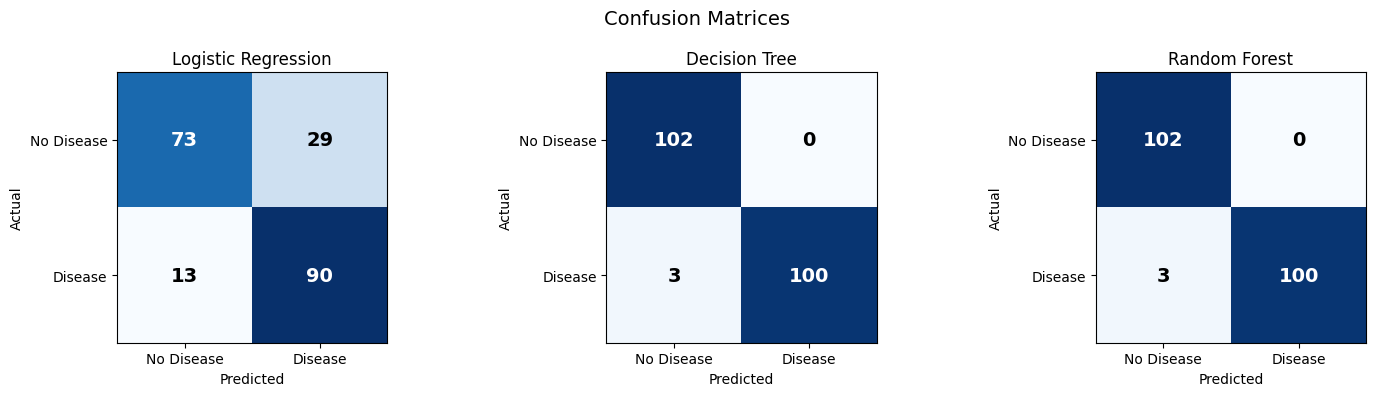


Detailed Report — Random Forest:
              precision    recall  f1-score   support

  No Disease       0.97      1.00      0.99       102
     Disease       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [8]:
# Confusion matrices for all 3 models

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices', fontsize=14)

for ax, name, pred in zip(axes, models, predictions):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Disease', 'Disease'])
    ax.set_yticklabels(['No Disease', 'Disease'])
    
    # Add numbers inside boxes
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                   ha='center', va='center',
                   color='white' if cm[i, j] > cm.max()/2 else 'black',
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed report for best model (Random Forest)
print("\nDetailed Report — Random Forest:")
print(classification_report(y_test, rf_pred,
      target_names=['No Disease', 'Disease']))

Checking for overfitting:

Model                      Train Acc   Test Acc   Difference
------------------------------------------------------------
Logistic Regression           0.8720     0.7951       0.0768
Decision Tree                 1.0000     0.9854       0.0146
Random Forest                 1.0000     0.9854       0.0146

Top 10 Most Important Features:
 feature  importance
      cp    0.135072
      ca    0.127327
 thalach    0.122169
 oldpeak    0.121905
    thal    0.110518
     age    0.077908
    chol    0.074822
trestbps    0.071171
   exang    0.057594
   slope    0.045782


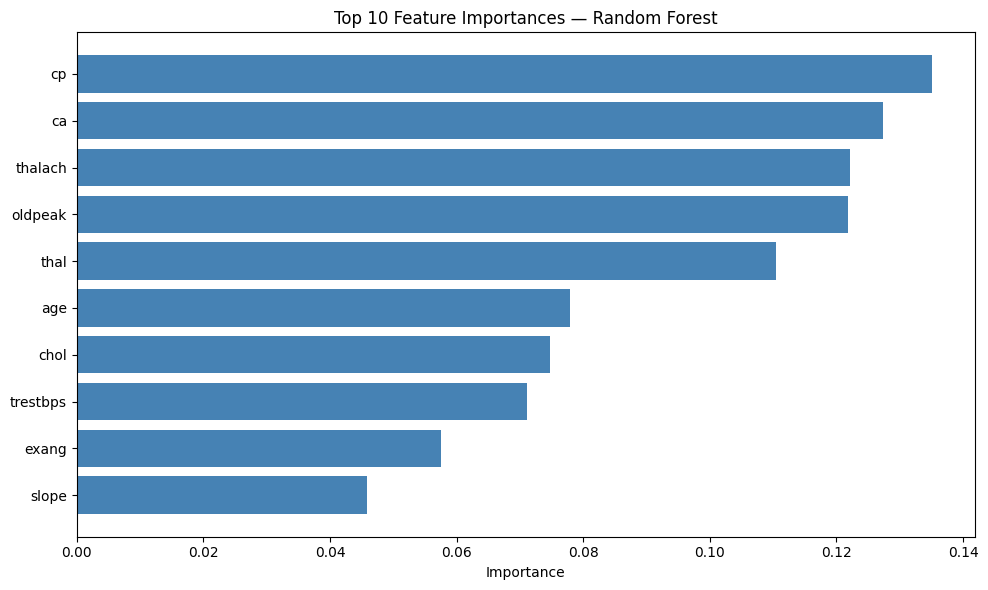

In [9]:
# Check for overfitting — compare train vs test accuracy

print("Checking for overfitting:\n")
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Difference':>12}")
print("-" * 60)

for name, model, pred in zip(models, [lr, dt, rf], predictions):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, pred)
    diff = train_acc - test_acc
    print(f"{name:<25} {train_acc:>10.4f} {test_acc:>10.4f} {diff:>12.4f}")

# Feature importance from Random Forest
print("\nTop 10 Most Important Features:")
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][:10], importance['importance'][:10], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# Save summary
print("=== Week 2 Summary ===")
print(f"Dataset: Heart Disease UCI (1025 patients, 13 features)")
print(f"Best Model: Random Forest")
print(f"Test Accuracy: 98.54%")
print(f"F1 Score: 98.52%")
print(f"Most Important Feature: Chest Pain Type (cp)")

=== Week 2 Summary ===
Dataset: Heart Disease UCI (1025 patients, 13 features)
Best Model: Random Forest
Test Accuracy: 98.54%
F1 Score: 98.52%
Most Important Feature: Chest Pain Type (cp)
